## 네이버 블로그 크롤링

In [1]:
# 라이브러리 불러오기
import pandas as pd # 데이터 조작 및 분석을 모듈
import time # 코드 실행 속도 조절을 위한 모듈
import re   # 정규표현식을 사용하여 텍스트에서 특수문자를 제거하거나 특정 패턴을 찾을 때 쓰는 모듈

from selenium import webdriver # 브라우저 자동화를 위한 모듈
from bs4 import BeautifulSoup as BS # HTML 내용 파싱을 위한 모듈
from selenium.webdriver.common.by import By # 다양한 방법으로 엘리먼트를 찾기 위한 모듈
from selenium.webdriver.support.ui import WebDriverWait # 브라우저가 요소를 찾을 때까지 대기(Wait)해주는 모듈
from selenium.webdriver.support import expected_conditions as EC # '어떤 상태'가 될 때까지 기다릴지 조건을 정해주는(EC) 기능 임포트

In [ ]:
# 브라우저 실행
driver = webdriver.Chrome()
# 브라우저 창 최대화 - 좋아요 수(공감 수)원활한 수집을 위해 : 최대화 안했을 때에 인식이 안됐던 점 보완
driver.maximize_window()

In [ ]:
import datetime # 날짜와 시간을 다루는 파이썬 기본 라이브러리

# 네이버 검색 결과의 무한 스크롤 특성으로 인해 처음 페이지에 접속하면 네이버는 서버 부하를 줄이기 위해 약 30개 정도의 글만 먼저 보여줌. 
# 따라서 사용자가 화면을 아래로 스크롤해야 추가로 글을 더 불러올 수 있음. -> 스코롤 다운 함수를 정의해 블로그 확보 갯수 조절 가능!

# 스크롤 다운 함수 정의
def doScrollDown(whileSeconds): 
    start = datetime.datetime.now() # 함수가 실행된 '현재 시점'의 시/분/초 가져오기
    end = start + datetime.timedelta(seconds=whileSeconds) # 입력받은 초 만큼의 시간 간격 생성
    while True:
        driver.execute_script('window.scrollTo(0, document.body.scrollHeight);') # 페이지 맨 아래로 스크롤 다운
        time.sleep(1.2) # 다음 목록이 로딩될 시간(약 1.2초)을 줌
        if datetime.datetime.now() > end: # 만약 현재 시간이 아까 계산해둔 종료 시간(end)보다 커지면 반복 break
            break 

In [ ]:
# (2026.02.28*미국 이란 전쟁 발발일*~2026.03.26) 동안 "미국 이란 전쟁"에 대한 네이버 블로그 검색 결과
naver_blog_url = 'https://search.naver.com/search.naver?ssc=tab.blog.all&query=%EB%AF%B8%EA%B5%AD%20%EC%9D%B4%EB%9E%80%20%EC%A0%84%EC%9F%81&sm=tab_opt&nso=so%3Ar%2Cp%3Afrom20260228to20260326'
driver.get(naver_blog_url)
time.sleep(2) # 검색 결과 로딩 대기

In [ ]:
# 2. 목록 확장을 위해 스크롤
doScrollDown(15)

In [ ]:
# [네이버 블로그 제목과 URL 추출 시작]

# 제목과 URL을 저장할 리스트 초기화 (나중에 카페와 구분하기 위해 blog_ 접두사 사용)
blog_title_list = []
blog_url_list = []

# 네이버가 최근 블로그 검색 결과 레이아웃을 업데이트하면서 클래스명이 무작위 문자열이 섞인 형태로 바뀐것을 F12키를 활용해 인지했습니다.
# 이런 클래스명은 네이버가 코드를 업데이트할 때마다 수시로 바뀌기 때문에, '클래스 이름' 대신 해당 클래스의 '구조'나 '속성'을 이용해 크롤링하는 것이 좋다고 느꼈습니다.
# <a> 태그 중에서 'data-heatmap-target' 속성값이 '.nblg'인 것만 골라내기
found_blog_elements = driver.find_elements(By.CSS_SELECTOR, 'a[data-heatmap-target=".nblg"]')

# 찾아낸 여러 개의 요소(found_blog_elements)를 하나씩 꺼내어 반복문 돌리기
for element in found_blog_elements:
    title_text = element.text.strip()
    url_link = element.get_attribute('href')
    
    if title_text and url_link: # 제목과 주소가 모두 정상적으로 존재할 때만 리스트에 추가 (빈 값 방지)
        blog_title_list.append(title_text) # 제목 리스트에 추가
        blog_url_list.append(url_link)     # 주소 리스트에 추가

# 중복 제거 (데이터 정제)
# 대량 수집 시 중복된 글을 피하기 위해 판다스 데이터프레임을 활용합니다.
df_blog_temp = pd.DataFrame({'title': blog_title_list, 'url': blog_url_list})

# subset=['url'] = 주소(url) 컬럼을 기준으로 중복된 블로그인지 검사해"라는 뜻
# keep='first' = 만약 똑같은 주소가 여러 개 발견되면, 가장 처음에 나온 것 하나만 남기고 나머지는 버려"라는 뜻
df_blog_temp = df_blog_temp.drop_duplicates(subset=['url'], keep='first')

# 중복 제거된 데이터를 다시 우리가 사용할 리스트로 변환
blog_title_list = df_blog_temp['title'].tolist()
blog_url_list = df_blog_temp['url'].tolist()

print(f"✅ 총 {len(blog_url_list)}개의 중복 없는 네이버 블로그 주소를 확보했습니다.")

✅ 총 420개의 중복 없는 네이버 블로그 주소를 확보했습니다.


In [ ]:
# --- [네이버 블로그 본문, 좋아요, 댓글, 이미지 및 영상 갯수 총 6개 항목 상세 수집 시작] ---
blog_new_doc = []      # 1. 본문
blog_like_cnt = []     # 2. 좋아요(공감) 수
blog_comment_cnt = []  # 3. 댓글 수
blog_comment_list = [] # 4. 댓글 내용
blog_img_cnt = []      # 5. 이미지 수
blog_div_cnt = []      # 6. 영상 수

# blog_url_list에 저장된 주소 개수만큼 반복문을 실행
for i in range(len(blog_url_list)): 
    driver.execute_script(f"window.open('{blog_url_list[i]}')")
    driver.switch_to.window(driver.window_handles[1]) # 새로 열린 탭(인덱스 1번)으로 제어권을 전환
    
    # 요소가 나타날 때까지만 최대 3초 대기하는 wait 설정
    wait = WebDriverWait(driver, 3) 
    
    try:
        # 네이버 블로그는 본문이 'mainFrame'이라는 iframe 안에 숨겨져 있어 전환이 필요
        # 프레임이 로딩되자마자 즉시 전환
        wait.until(EC.frame_to_be_available_and_switch_to_it((By.ID, 'mainFrame')))
        
        html = driver.page_source
        soup = BS(html, 'html.parser')
        
        # 1. 본문 추출
        try:
            content = soup.select_one('.se-main-container, #postViewArea').get_text(strip=True)
        except: # 본문을 찾을 수 없는 경우
            content = "null"
        blog_new_doc.append(content)

        # 2. 좋아요(공감) 추출
        try:
            driver.execute_script("window.scrollTo(0, document.body.scrollHeight);") # 화면 아래에 있어야 공감 버튼 요소가 활성화되는 경우가 많아 바닥으로 스크롤
            
            # 좋아요 숫자가 보일 때까지만 딱 대기 (최대 2초)
            like_el = WebDriverWait(driver, 2).until(EC.presence_of_element_located((By.CSS_SELECTOR, "span.u_likeit_text._count.num")))
            like_val = like_el.get_attribute('textContent').strip() # .text 대신 'textContent'를 사용 -> 숨겨진 숫자까지 강제로 가져오기
            if not like_val or not like_val.isdigit(): like_val = "0" # 숫자가 비어있거나 숫자가 아니면 '0'으로 처리
        except:
            like_val = "0"
        blog_like_cnt.append(like_val)

        # 3. 댓글 수 추출
        try:
            comment_num = driver.find_element(By.ID, "commentCount").get_attribute('textContent').strip()
            if not comment_num: comment_num = "0"
        except:
            comment_num = "0"
        blog_comment_cnt.append(comment_num)

        # 4. 이미지/영상 수 추출
        # BeautifulSoup의 select 기능을 사용하여 이미지 태그와 영상 관련 클래스의 개수 세기
        blog_img_cnt.append(len(soup.select('img.se-image-resource')))
        blog_div_cnt.append(len(soup.select('.pzp-ui-dimmed, .se-video-container')))

        # 5. 댓글 내용 추출
        try:
            comment_btn = driver.find_element(By.ID, "commentCount") # 댓글 버튼을 찾아 자바스크립트로 강제 클릭
            driver.execute_script("arguments[0].click();", comment_btn) 
            time.sleep(1) 
            comments = driver.find_elements(By.CLASS_NAME, "u_cbox_contents") # 댓글 내용이 담긴 요소들 모두 찾기
            # 댓글 창은 정상적으로 열렸으나, 실제로 작성된 댓글이 0개인 경우
            blog_comment_final = "\n".join([c.text for c in comments]) if comments else "댓글 없음" 
        except:
            # 블로그 주인이 댓글 기능을 아예 막아 놓은 경우 (commentCount 요소를 찾지 못함)
            blog_comment_final = "댓글 막힘" 
        blog_comment_list.append(blog_comment_final)

    except Exception as e:
        print(f"⚠️ {i+1}번 글 오류: {e}")
        # 오류 시에도 리스트 길이를 맞추기 위해 기본값 삽입
        blog_new_doc.append("error")
        blog_like_cnt.append("0")
        blog_comment_cnt.append("0")
        blog_comment_list.append("error")
        blog_img_cnt.append(0)
        blog_div_cnt.append(0)

    # 작업이 끝난 탭을 닫고 다시 메인 목록 탭(인덱스 0번)으로 돌아가기
    driver.close()
    driver.switch_to.window(driver.window_handles[0])
    
    # 잘 되고 있는지 10개마다 진행 상황 출력
    if (i + 1) % 10 == 0:
        print(f"[네이버 블로그] 진행 상황: {i+1}/{len(blog_url_list)} 완료")

driver.quit() # 브라우저 종료
print("수집 프로세스 종료!")

[네이버 블로그] 진행 상황: 10/420 완료
[네이버 블로그] 진행 상황: 20/420 완료
[네이버 블로그] 진행 상황: 30/420 완료
[네이버 블로그] 진행 상황: 40/420 완료
[네이버 블로그] 진행 상황: 50/420 완료
[네이버 블로그] 진행 상황: 60/420 완료
[네이버 블로그] 진행 상황: 70/420 완료
[네이버 블로그] 진행 상황: 80/420 완료
[네이버 블로그] 진행 상황: 90/420 완료
[네이버 블로그] 진행 상황: 100/420 완료
[네이버 블로그] 진행 상황: 110/420 완료
[네이버 블로그] 진행 상황: 120/420 완료
[네이버 블로그] 진행 상황: 130/420 완료
[네이버 블로그] 진행 상황: 140/420 완료
[네이버 블로그] 진행 상황: 150/420 완료
[네이버 블로그] 진행 상황: 160/420 완료
[네이버 블로그] 진행 상황: 170/420 완료
[네이버 블로그] 진행 상황: 180/420 완료
[네이버 블로그] 진행 상황: 190/420 완료
[네이버 블로그] 진행 상황: 200/420 완료
[네이버 블로그] 진행 상황: 210/420 완료
[네이버 블로그] 진행 상황: 220/420 완료
[네이버 블로그] 진행 상황: 230/420 완료
[네이버 블로그] 진행 상황: 240/420 완료
[네이버 블로그] 진행 상황: 250/420 완료
[네이버 블로그] 진행 상황: 260/420 완료
[네이버 블로그] 진행 상황: 270/420 완료
[네이버 블로그] 진행 상황: 280/420 완료
[네이버 블로그] 진행 상황: 290/420 완료
[네이버 블로그] 진행 상황: 300/420 완료
[네이버 블로그] 진행 상황: 310/420 완료
[네이버 블로그] 진행 상황: 320/420 완료
[네이버 블로그] 진행 상황: 330/420 완료
[네이버 블로그] 진행 상황: 340/420 완료
[네이버 블로그] 진행 상황: 350/420 완료
[네이버 블로그] 진행 상황: 360/420 완료
[

In [ ]:
# --- [네이버 블로그 최종 데이터프레임 생성 및 저장] ---

# 태하 님이 제안하신 구조를 바탕으로, 수집된 리스트들을 하나의 표로 합칩니다.
# 'ch'와 'ch2' 컬럼을 추가하여 나중에 카페 데이터와 섞여도 출처를 바로 알 수 있게 합니다.
df_blog = pd.DataFrame({
    'title': blog_title_list,      # 글 제목
    'url': blog_url_list,          # 글 주소 (원문 확인해야 할 상황 대비)
    'doc': blog_new_doc,           # 본문 내용
    'like': blog_like_cnt,         # 좋아요(공감) 수
    'comment_cnt': blog_comment_cnt, # 댓글 수
    'comment_list': blog_comment_list, # 댓글 내용
    'img': blog_img_cnt,           # 이미지 개수
    'div': blog_div_cnt,           # 영상 개수
    'ch': 'naver',                 # 채널 구분 1 (네이버/다음)
    'ch2': 'blog'                  # 채널 구분 2 (블로그/카페)
})

# 데이터 확인 (잘 들어갔는지 상위 5개 미리보기)
print("📊 네이버 블로그 데이터 생성 완료 (상위 5행):")
print(df_blog.head())

# 파일 저장 (파일명 규칙: naver_blog_data.csv)
file_name = 'naver_blog_data.csv'
df_blog.to_csv(file_name, index=False, encoding='utf-8-sig')

print(f"{file_name} 저장 완료! 이제 카페 수집으로 넘어갈 준비가 되었습니다.")

📊 네이버 블로그 데이터 생성 완료 (상위 5행):
                                        title  \
0           미국 이란 전쟁 5일간 휴전, 코스피 나스닥 불반등 시작될까   
1        미국-이란 전쟁 '유가 100달러' 시대… 에너지 취약계층 그림자   
2                 미국-이란 전쟁 확산에, 코스피 급락·방산주 폭등   
3  트럼프 미국 이란 전쟁 진짜 이유 뒤에 숨겨진 거대 자본의 소름 끼치는 설계   
4           미국 이란 전쟁 이유, 우리나라 경제 주가에 미치는 영향은?   

                                                 url  \
0    https://blog.naver.com/mellongi123/224227202490   
1  https://blog.naver.com/energyinfoplaza/2242178...   
2     https://blog.naver.com/newsystock/224202772150   
3        https://blog.naver.com/abcde10/224230745437   
4      https://blog.naver.com/kimgr1010/224220542560   

                                                 doc like comment_cnt  \
0  그야말로 도박장 같은 주식시장이다. 시퍼렇게 물들었던 계좌였는데 이제는 미국-이란 ...   43           5   
1  미국-이란 전쟁 '유가 100달러' 시대…에너지 취약계층 그림자세계는 다시 전쟁의 ...   38          19   
2  미국-이란 전쟁 확산에,코스피 급락·방산주 폭등​미국-이란 전쟁이 확장되며 호르무즈...   13           3   
3  ​​트럼프 미국 이란 전쟁 진짜 이유 뒤에 숨겨진 거대 자본의 소름 끼치는 설계

In [ ]:
# 브라우저 실행
driver = webdriver.Chrome()
# 브라우저 창 최대화 - 좋아요 수(공감 수)원활한 수집을 위해 : 최대화 안했을 때에 인식이 안됐던 점 보완
driver.maximize_window()

In [ ]:
# (2026.02.28*미국 이란 전쟁 발발일*~2026.03.26) 동안 "미국 이란 전쟁"에 대한 네이버 카페 검색 결과
# 네이버 카페 검색 옵션에서 '일반글' 선택으로 불필요한 데이터인 '거래글'수집 사전 차단.
naver_cafe_url = "https://search.naver.com/search.naver?cafe_where=articleg&nso=so%3Ar%2Cp%3Afrom20260228to20260326&nso_open=1&prdtype=0&query=%EB%AF%B8%EA%B5%AD+%EC%9D%B4%EB%9E%80+%EC%A0%84%EC%9F%81&sm=mtb_opt&ssc=tab.cafe.all&st=rel&stnm=rel&opt_tab=0&nso=so%3Ar%2Cp%3Afrom20260228to20260326&date_from=20260228&date_to=20260326"
driver.get(naver_cafe_url)
time.sleep(2) # 페이지 로딩 대기

In [ ]:
# 2. 목록 확장을 위해 스크롤
doScrollDown(15)

In [ ]:
# --- [네이버 카페 제목과 URL 추출 시작] ---

# 제목과 URL을 저장할 리스트 초기화 (나중에 블로그와 구분하기 위해 cafe_ 접두사 사용)
cafe_title_list = []
cafe_url_list = []

# BeautifulSoup으로 현재 페이지의 HTML 소스를 가져옵니다. (속도 최적화를 위해 BS 활용)
html = driver.page_source
soup = BS(html, 'html.parser')

# 네이버 카페 검색 결과의 게시글 요소들을 선택합니다.
# 카페 역시 클래스명이 바뀔 수 있으므로, 공통적인 구조인 '.view_wrap' 내부의 '.title_link'를 활용합니다.
found_cafe_elements = soup.select('.view_wrap .title_link')

# 찾아낸 여러 개의 요소들을 하나씩 꺼내어 반복문을 돌립니다.
for element in found_cafe_elements:
    title_text = element.get_text(strip=True)
    url_link = element['href']
    
    if title_text and url_link: # 제목과 주소가 모두 정상적으로 존재할 때만 리스트에 추가 (빈 값 방지)
        cafe_title_list.append(title_text) # 제목 리스트에 추가
        cafe_url_list.append(url_link)     # 주소 리스트에 추가

# [중복 제거 - 데이터 정제]
# 대량 수집 시 중복된 글을 피하기 위해 판다스 데이터프레임을 활용합니다.
df_cafe_temp = pd.DataFrame({'title': cafe_title_list, 'url': cafe_url_list})

# 주소(url) 컬럼을 기준으로 중복된 카페 글인지 검사하여 첫 번째 것만 남깁니다.
df_cafe_temp = df_cafe_temp.drop_duplicates(subset=['url'], keep='first')

# 중복 제거된 데이터를 다시 우리가 상세 수집에서 사용할 리스트로 변환
cafe_title_list = df_cafe_temp['title'].tolist()
cafe_url_list = df_cafe_temp['url'].tolist()

print(f"✅ 총 {len(cafe_url_list)}개의 중복 없는 네이버 카페 주소를 확보했습니다.")

✅ 총 420개의 중복 없는 네이버 카페 주소를 확보했습니다.


In [ ]:
# --- [네이버 카페 본문, 좋아요, 댓글, 이미지 및 영상 갯수 총 6개 항목 상세 수집 시작] ---

# 데이터를 저장할 리스트들 초기화 (네이버 카페용 접두사 cafe_ 사용)
cafe_new_doc = []      # 1. 본문
cafe_like_cnt = []     # 2. 좋아요(공감) 수
cafe_comment_cnt = []  # 3. 댓글 수
cafe_comment_list = [] # 4. 댓글 내용
cafe_img_cnt = []      # 5. 이미지 수
cafe_div_cnt = []      # 6. 영상 수

# cafe_url_list에 저장된 주소 개수만큼 반복문을 실행
# --- [네이버 카페 상세 수집] ---

for i in range(len(cafe_url_list)): 
    driver.execute_script(f"window.open('{cafe_url_list[i]}')")
    driver.switch_to.window(driver.window_handles[1])
    
    wait = WebDriverWait(driver, 3)
    
    try:
        # 1. 프레임 전환
        wait.until(EC.frame_to_be_available_and_switch_to_it((By.ID, 'cafe_main')))
        time.sleep(0.5) # 안정적인 로딩을 위해 살짝 대기
        
        html = driver.page_source
        soup = BS(html, 'html.parser')
        
        # 1. 본문 추출
        try:
            content = soup.select_one('.se-main-container, .ContentRenderer, .article_viewer').get_text(strip=True)
        except: content = "내용 없음"
        cafe_new_doc.append(content)

        # 2. 좋아요 추출
        try:
            driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
            # a.like_count_btn 태그 안의 텍스트를 가져옵니다.
            like_el = WebDriverWait(driver, 2).until(EC.presence_of_element_located((By.CSS_SELECTOR, "em.u_cnt._count")))
            like_val = like_el.get_attribute('textContent').strip()
            if not like_val or not like_val.isdigit(): like_val = "0" # 숫자가 비어있거나 숫자가 아니면 '0'으로 처리
        except: like_val = "0"
        cafe_like_cnt.append(like_val)

        # 3. 댓글 수 추출
        try:
            # 댓글창 영역 근처의 strong.num을 찾습니다.
            comment_num_el = driver.find_element(By.CSS_SELECTOR, "strong.num, .comment_count")
            comment_num = comment_num_el.get_attribute('textContent').strip()
            comment_num = re.sub(r'[^0-9]', '', comment_num)
            if not comment_num: comment_num = "0"
        except: comment_num = "0"
        cafe_comment_cnt.append(comment_num)

        # 4. 이미지 및 영상 수 추출
        # 이미지: 클래스가 se-image-resource인 것들 중 .gif(움짤/영상)가 아닌 것만 필터링
        all_imgs = soup.select('img.se-image-resource')
        
        # 영상(움짤 포함): 확장자가 gif거나 특정 영상 클래스를 포함하는 경우
        # gif도 영상 수에 포함시키도록 설정
        video_list = [img for img in all_imgs if '.gif' in img.get('src', '').lower()]
        image_list = [img for img in all_imgs if '.gif' not in img.get('src', '').lower()]
        
        cafe_img_cnt.append(len(image_list))
        # 기존 영상 태그(.pzp-ui-dimmed 등)와 gif 리스트를 합산
        cafe_div_cnt.append(len(video_list) + len(soup.select('.pzp-ui-dimmed, .se-video-container')))

        # 5. 댓글 내용 추출
        try:
            comment_btn = driver.find_element(By.CSS_SELECTOR, "a.button_comment, .btn_comment")
            driver.execute_script("arguments[0].click();", comment_btn) 
            time.sleep(1) 
            comments = driver.find_elements(By.CLASS_NAME, "comment_text_view")
            cafe_comment_final = "\n".join([c.text for c in comments]) if comments else "댓글 없음"
        except:
            cafe_comment_final = "댓글 막힘" 
        cafe_comment_list.append(cafe_comment_final)

    except Exception as e:
        print(f"⚠️ {i+1}번 카페 글 오류: {e}")
        cafe_new_doc.append("에러 발생"); cafe_like_cnt.append("0"); cafe_comment_cnt.append("0")
        cafe_comment_list.append("에러 발생"); cafe_img_cnt.append(0); cafe_div_cnt.append(0)

    driver.close()
    driver.switch_to.window(driver.window_handles[0])
    
    if (i + 1) % 10 == 0:
        print(f"[네이버 카페] 진행 상황: {i+1}/{len(cafe_url_list)} 완료")

driver.quit() # 브라우저 종료
print("수집 프로세스 종료!")

[네이버 카페] 진행 상황: 10/420 완료
[네이버 카페] 진행 상황: 20/420 완료
[네이버 카페] 진행 상황: 30/420 완료
[네이버 카페] 진행 상황: 40/420 완료
[네이버 카페] 진행 상황: 50/420 완료
[네이버 카페] 진행 상황: 60/420 완료
[네이버 카페] 진행 상황: 70/420 완료
[네이버 카페] 진행 상황: 80/420 완료
[네이버 카페] 진행 상황: 90/420 완료
[네이버 카페] 진행 상황: 100/420 완료
[네이버 카페] 진행 상황: 110/420 완료
[네이버 카페] 진행 상황: 120/420 완료
[네이버 카페] 진행 상황: 130/420 완료
[네이버 카페] 진행 상황: 140/420 완료
[네이버 카페] 진행 상황: 150/420 완료
[네이버 카페] 진행 상황: 160/420 완료
[네이버 카페] 진행 상황: 170/420 완료
[네이버 카페] 진행 상황: 180/420 완료
[네이버 카페] 진행 상황: 190/420 완료
[네이버 카페] 진행 상황: 200/420 완료
[네이버 카페] 진행 상황: 210/420 완료
[네이버 카페] 진행 상황: 220/420 완료
[네이버 카페] 진행 상황: 230/420 완료
[네이버 카페] 진행 상황: 240/420 완료
[네이버 카페] 진행 상황: 250/420 완료
[네이버 카페] 진행 상황: 260/420 완료
[네이버 카페] 진행 상황: 270/420 완료
[네이버 카페] 진행 상황: 280/420 완료
[네이버 카페] 진행 상황: 290/420 완료
[네이버 카페] 진행 상황: 300/420 완료
[네이버 카페] 진행 상황: 310/420 완료
[네이버 카페] 진행 상황: 320/420 완료
[네이버 카페] 진행 상황: 330/420 완료
[네이버 카페] 진행 상황: 340/420 완료
[네이버 카페] 진행 상황: 350/420 완료
[네이버 카페] 진행 상황: 360/420 완료
[네이버 카페] 진행 상황: 370/420 완료
[네이버 카페] 진

In [ ]:
# 상세 수집 단계에서 사용한 변수명과 동일하게 매칭
df_cafe = pd.DataFrame({
    'title': cafe_title_list,       # 카페 글 제목
    'url': cafe_url_list,           # 카페 글 주소
    'doc': cafe_new_doc,            # 카페 본문 내용
    'like': cafe_like_cnt,          # 좋아요 수 (F12로 찾은 like_count_btn 결과)
    'comment_cnt': cafe_comment_cnt, # 댓글 수 (F12로 찾은 strong.num 결과)
    'comment_list': cafe_comment_list, # 댓글 상세 내용 (댓글 막힘 포함)
    'img': cafe_img_cnt,            # 이미지 개수 (gif 제외)
    'div': cafe_div_cnt,            # 영상 및 움짤(gif) 개수
    'ch': 'naver',                  # 채널 구분 1
    'ch2': 'cafe'                   # 채널 구분 2
})

# 2. 데이터가 잘 들어갔는지 상위 5개 미리보기
print("📊 [검토] 네이버 카페 데이터프레임 상위 5행:")
print(df_cafe.head())

# 3. 엑셀에서 바로 열 수 있도록 CSV 파일로 저장
# 파일명: naver_cafe_data.csv
file_name = 'naver_cafe_data.csv'
df_cafe.to_csv(file_name, index=False, encoding='utf-8-sig')

print(f"\n💾 저장 완료! 파일명: {file_name}")
print(f"✅ 총 {len(df_cafe)}개의 카페 데이터가 정상적으로 기록되었습니다.")

📊 [검토] 네이버 카페 데이터프레임 상위 5행:
                  title                                                url  \
0    미국.이란 전쟁종식 시점 발표..  https://cafe.naver.com/ustock/5051217?art=ZXh0...   
1       미국-이란 전쟁타임라인 정리  https://cafe.naver.com/ralo24/186660?art=ZXh0Z...   
2       미국 이란 전쟁이유와 수혜주  https://cafe.naver.com/specup/7754714?art=ZXh0...   
3         미국 이란 전쟁예상도..  https://cafe.naver.com/likeusstock/1390157?art...   
4  미국-이란 전쟁요점만 정리해드립니다.  https://cafe.naver.com/dlxogns01/362930?art=ZX...   

                                                 doc like comment_cnt  \
0  게시판 안내를 확인해 주세요![필독] 평생주식카페는 6개월간 활동내용을 토대로 등급...   19          20   
1                                              내용 없음   22           0   
2  게시판 안내를 확인해 주세요!💭실시간 채용속보 받아보기 :https://vo.la/...    8          16   
3  게시판 안내를 확인해 주세요!👉우리 카페 활동에 필요한 주의사항 👈https://c...   19           6   
4  게시판 안내를 확인해 주세요!*** 자유게시판, 고민게시판에 투자 관련된 (주식, ...   77           0   

                                        comment_list  img  div  

In [ ]:
# 브라우저 실행
driver = webdriver.Chrome()
driver.maximize_window()

In [ ]:
# (2026.02.28*미국 이란 전쟁 발발일*~2026.03.26) 동안 "미국 이란 전쟁"에 대한 다음 카페 검색 결과
daum_cafe_url = 'https://search.daum.net/search?w=fusion&nil_search=btn&DA=STC&q=%EB%AF%B8%EA%B5%AD+%EC%9D%B4%EB%9E%80+%EC%A0%84%EC%9F%81&col=cafe&sd=20260228000000&ed=20260326235959&period=u'
driver.get(daum_cafe_url)
time.sleep(2) # 검색 결과 로딩 대기

In [ ]:
# 1. 리스트 초기화
daum_cafe_title_list = []  
daum_cafe_url_list = []     

# 검색어와 날짜 범위를 그대로 유지
base_url = "https://search.daum.net/search?w=fusion&nil_search=btn&DA=STC&q=%EB%AF%B8%EA%B5%AD+%EC%9D%B4%EB%9E%80+%EC%A0%84%EC%9F%81&col=cafe&sd=20260228000000&ed=20260326235959&period=u&p={}"

page_num = 1
target_count = 420  # 목표 개수 설정 :420

while len(daum_cafe_url_list) < target_count:
    # 해당 페이지로 강제 이동
    current_url = base_url.format(page_num)
    driver.get(current_url)
    time.sleep(2.5) # 다음 서버 부하 방지 및 로딩 대기
    
    # 현재 화면의 카드들 찾기
    cards = driver.find_elements(By.TAG_NAME, 'c-card')
    
    # 만약 페이지에 카드가 하나도 없다면 (검색 결과 끝) 종료
    if not cards:
        print(f"🏁 더 이상 검색 결과가 없습니다. (현재 수집량: {len(daum_cafe_url_list)}개)")
        break
        
    for card in cards:
        # 목표 개수 도달 시 즉시 중단
        if len(daum_cafe_url_list) >= target_count:
            break
            
        try:
            # 제목과 URL 추출 (c-title 태그 활용)
            title_el = card.find_element(By.TAG_NAME, 'c-title')
            title_text = title_el.text.strip()
            url_link = title_el.get_attribute('data-href')
            
            # 중복 체크 후 리스트에 담기
            if url_link not in daum_cafe_url_list:
                daum_cafe_title_list.append(title_text)
                daum_cafe_url_list.append(url_link)
        except:
            continue
    
    # 진행 상황 출력 (10단위로 끊어서 확인)
    if len(daum_cafe_url_list) % 10 == 0 or len(daum_cafe_url_list) == target_count:
        print(f"진행 상황: {len(daum_cafe_url_list)}/{target_count} 완료 (현재 {page_num}페이지)")

    # 다음 페이지 번호로 증가
    page_num += 1
    
    # 너무 무한 루프에 빠지지 않도록 최대 페이지 제한 (예: 50페이지)
    if page_num > 50:
        print("⚠️ 최대 페이지 제한(50p)에 도달하여 수집을 중단합니다.")
        break

# 2. 최종 데이터 정제 및 결과 출력
df_daum_list = pd.DataFrame({
    'title': daum_cafe_title_list,
    'url': daum_cafe_url_list
})

print(f"✅ 수집 프로세스 종료! 총 {len(df_daum_list)}개의 주소를 확보했습니다.")

진행 상황: 30/420 완료 (현재 3페이지)
진행 상황: 60/420 완료 (현재 5페이지)
진행 상황: 90/420 완료 (현재 7페이지)
진행 상황: 120/420 완료 (현재 9페이지)
진행 상황: 150/420 완료 (현재 11페이지)
🏁 더 이상 검색 결과가 없습니다. (현재 수집량: 157개)
✅ 수집 프로세스 종료! 총 157개의 주소를 확보했습니다.


In [ ]:
# 1. 데이터를 저장할 리스트들 초기화 (다음 카페용 접두사 daum_cafe_ 사용)
daum_cafe_doc_list = []
daum_cafe_like_cnt = []
daum_cafe_comment_cnt = []
daum_cafe_comment_list = []
daum_cafe_img_cnt = []
daum_cafe_video_cnt = []

for i, url in enumerate(daum_cafe_url_list):
    try:
        driver.get(url)
        time.sleep(3) # 페이지 로딩 대기
        
        # [프레임 전환]
        iframes = driver.find_elements(By.TAG_NAME, "iframe")
        found_frame = False
        for frame in iframes:
            f_name = frame.get_attribute('name') or frame.get_attribute('id')
            if f_name in ['down_frame', 'iframename']:
                driver.switch_to.frame(frame)
                found_frame = True
                break
        
        if not found_frame:
            try: driver.switch_to.frame(0); found_frame = True
            except: pass

        if found_frame:
            # 로딩을 위해 스크롤 다운
            driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
            time.sleep(1.5)
            
            # 1. 본문 (그물망 전략)
            doc_text = "내용 없음"
            for selector in ['#article', '.tx-content-container', '.cont_view', 'body']:
                try:
                    target = driver.find_element(By.CSS_SELECTOR, selector)
                    if target.text.strip():
                        doc_text = target.text.strip().replace('\n', ' ')
                        break
                except: continue
            daum_cafe_doc_list.append(doc_text)

            # 2. 추천 수(좋아요 수)
            try:
                like_val = re.sub(r'[^0-9]', '', driver.find_element(By.CSS_SELECTOR, '.txt_item, .num_vote').text)
                if not like_val: like_val = "0"
            except: like_val = "0"
            daum_cafe_like_cnt.append(like_val)

            # 3. 댓글 내용 및 수
            try:
                comment_elements = driver.find_elements(By.CSS_SELECTOR, '.original_comment')
                c_list = [c.text.strip() for c in comment_elements if c.text.strip()]
                
                # 댓글 리스트의 개수를 숫자로 변환
                c_cnt = str(len(c_list))
                c_text = " | ".join(c_list) if c_list else "댓글 막힘"
            except:
                c_cnt = "0"
                c_text = "댓글 막힘"
            
            daum_cafe_comment_cnt.append(c_cnt)    # 매 루프마다 추가!
            daum_cafe_comment_list.append(c_text)  # 매 루프마다 추가!

            # 4. 이미지 및 영상 수
            i_cnt = len(driver.find_elements(By.CSS_SELECTOR, '.txc-image, img'))
            v_cnt = len(driver.find_elements(By.CSS_SELECTOR, '.cover_image_wrap, video, iframe[src*="youtube"]'))
            
            daum_cafe_img_cnt.append(i_cnt)
            daum_cafe_video_cnt.append(v_cnt)
        
        else:
            raise Exception("프레임 진입 실패")

        # 프레임 탈출
        driver.switch_to.default_content()

    except Exception as e:
        # 에러 발생 시에도 리스트 길이를 맞추기 위해 기본값 삽입 (네이버 코드 로직)
        print(f"⚠️ {i+1}번 다음 카페 글 오류: {e}")
        daum_cafe_doc_list.append("에러 발생")
        daum_cafe_like_cnt.append("0")
        daum_cafe_comment_cnt.append("0")
        daum_cafe_comment_list.append("댓글 막힘")
        daum_cafe_img_cnt.append(0)
        daum_cafe_video_cnt.append(0)
        driver.switch_to.default_content()

    if (i + 1) % 10 == 0:
        print(f"[다음 카페] 진행 상황: {i+1}/{len(daum_cafe_url_list)} 완료")

print("✅ 다음 카페 수집 완료!")

[다음 카페] 진행 상황: 10/157 완료
[다음 카페] 진행 상황: 20/157 완료
[다음 카페] 진행 상황: 30/157 완료
[다음 카페] 진행 상황: 40/157 완료
[다음 카페] 진행 상황: 50/157 완료
[다음 카페] 진행 상황: 60/157 완료
[다음 카페] 진행 상황: 70/157 완료
[다음 카페] 진행 상황: 80/157 완료
[다음 카페] 진행 상황: 90/157 완료
[다음 카페] 진행 상황: 100/157 완료
[다음 카페] 진행 상황: 110/157 완료
[다음 카페] 진행 상황: 120/157 완료
[다음 카페] 진행 상황: 130/157 완료
[다음 카페] 진행 상황: 140/157 완료
[다음 카페] 진행 상황: 150/157 완료
✅ 다음 카페 수집 완료!


In [ ]:
driver.quit() # 브라우저 종료

In [ ]:
# 1. 상세 수집 단계에서 사용한 다음 카페 변수명과 동일하게 매칭
df_daum_cafe = pd.DataFrame({
    'title': daum_cafe_title_list,       # 카페 글 제목
    'url': daum_cafe_url_list,           # 카페 글 주소
    'doc': daum_cafe_doc_list,           # 카페 본문 내용 (정밀 수집 결과)
    'like': daum_cafe_like_cnt,          # 추천 수 (.txt_item)
    'comment_cnt': daum_cafe_comment_cnt, # 댓글 수 (직접 카운팅 결과)
    'comment_list': daum_cafe_comment_list, # 댓글 상세 내용 (댓글 막힘 포함)
    'img': daum_cafe_img_cnt,             # 이미지 개수 (.txc-image)
    'div': daum_cafe_video_cnt,           # 영상 및 움짤 개수 (.cover_image_wrap)
    'ch': 'daum',                         # 채널 구분 1
    'ch2': 'cafe'                         # 채널 구분 2
})

# 2. 데이터가 잘 들어갔는지 상위 5개 미리보기
print("[검토] 다음 카페 데이터프레임 상위 5행:")
# 주요 데이터 위주로 먼저 확인합니다.
print(df_daum_cafe[['title', 'like', 'comment_cnt', 'div', 'doc']].head())

# 3. 엑셀에서 바로 열 수 있도록 CSV 파일로 저장
# 파일명: daum_cafe_data.csv
file_name = 'daum_cafe_data.csv'
df_daum_cafe.to_csv(file_name, index=False, encoding='utf-8-sig')

print(f"\n저장 완료! 파일명: {file_name}")
print(f"✅ 총 {len(df_daum_cafe)}개의 다음 카페 데이터가 정상적으로 기록되었습니다.")

[검토] 다음 카페 데이터프레임 상위 5행:
                           title like comment_cnt  div  \
0  "누가 물러나야 하나"…미국·이란 전쟁 끝낼 조건은?    0           0    0   
1  현재 트럼프의 오판으로 이상하게 됐다는 미국vs...    0          28    6   
2  미국-이란 전쟁 과연 어디로? 충격적인 이 내용...    3           2    0   
3          미국·이란 전쟁을 둘러싼 오해 [기고]    0           0    0   
4  미국 이란 전쟁.....쉽게 끝날지 걱정이 된다...    0           0    0   

                             doc  
0                          내용 없음  
1  출처: 여성시대 스피또띠아        전쟁 상...  
2  오늘 옛 트위터(현 X) 에 올라온 내용을 공유...  
3  미국·이란 전쟁을 둘러싼 오해 [기고] / 3월...  
4  기뢰는 설치는 쉽지만......제거하기는 어렵다...  

저장 완료! 파일명: daum_cafe_data.csv
✅ 총 157개의 다음 카페 데이터가 정상적으로 기록되었습니다.


In [ ]:
# 1. [전처리] 특수문자 제거 함수 정의
def clean_text(text):
    if pd.isna(text) or str(text).strip() == "": 
        return ""
    # 특수문자 제거
    cleaned = re.sub("[^0-9a-zA-Zㄱ-ㅎㅏ-ㅣ가-힣 ]", '', str(text))
    # 중복 공백 제거 및 양끝 공백 정리
    cleaned = ' '.join(cleaned.split())
    return cleaned

print(" 데이터 통합 및 전처리를 시작합니다 ")

try:
    # 2. 개별 수집 데이터 불러오기
    df_nb = pd.read_csv('naver_blog_data.csv')
    df_nc = pd.read_csv('naver_cafe_data.csv')
    df_dc = pd.read_csv('daum_cafe_data.csv')

    # 3. 데이터 통합 (Merge)
    raw_data = pd.concat([df_nb, df_nc, df_dc], ignore_index=True)
    initial_count = len(raw_data)

    # 4. [정제] 제목(title), 본문(doc), 댓글(comment_list) 모두 적용
    cols_to_clean = ['title', 'doc', 'comment_list']
    for col in cols_to_clean:
        if col in raw_data.columns:
            raw_data[col] = raw_data[col].apply(clean_text)
            # 정제 후 빈 값이 된 경우 '내용없음'으로 채움 (데이터 구조 유지)
            raw_data[col] = raw_data[col].replace('', '내용없음')

    # 5. [필터링] 본문(doc)이 2글자 미만인 행 삭제 (노이즈 제거)
    raw_data = raw_data[raw_data['doc'].str.len() >= 2]

    # 6. 인덱스 재설정 (삭제된 행 번호 정리)
    raw_data = raw_data.reset_index(drop=True)
    final_count = len(raw_data)

    # 7. 최종 파일 저장
    file_base_name = 'final_data_cleaned'
    
    # CSV 저장 (utf-8-sig로 엑셀 한글 깨짐 방지)
    raw_data.to_csv(f'{file_base_name}.csv', index=False, encoding='utf-8-sig')
    # Excel 저장
    raw_data.to_excel(f'{file_base_name}.xlsx', index=False)

    print("-" * 30)
    print(f"작업이 완료되었습니다!")
    print(f"📁 생성 파일: {file_base_name}.csv / {file_base_name}.xlsx")
    print("-" * 30)

except Exception as e:
    print(f"❌ 오류 발생: {e}")

 데이터 통합 및 전처리를 시작합니다 
------------------------------
작업이 완료되었습니다!
📁 생성 파일: final_data_cleaned.csv / final_data_cleaned.xlsx
------------------------------


# 결측값 정리 & 토큰화 및 형태소 분석

### tqdm : 진행상황 상태를 사용자에게 바로 피드백해주는 라이브러리 -> 사용 권장!

In [1]:
import pandas as pd
import os

# 파일 경로 설정
file_path = 'final_data_cleaned.csv'

# 파일이 존재하는지 확인 후 불러오기
if os.path.exists(file_path):
    raw_data = pd.read_csv(file_path)
    print(f"✅ 파일을 성공적으로 불러왔습니다! (데이터 개수: {len(raw_data)}개)")
else:
    
    print("❌ 파일이 없습니다. 수집 코드를 먼저 실행해야 합니다.")

✅ 파일을 성공적으로 불러왔습니다! (데이터 개수: 997개)


In [2]:
# 1. 원본 데이터 개수 확인 (불러온 raw_data를 df로 복사해서 사용)
df = raw_data.copy()
original_cnt = len(df)

# 2. 결측값 및 단문 정리 (본문 & 댓글 통합)
# .str.strip()으로 양쪽 공백을 제거한 후, 실제 글자 수가 2자 이상인 행만 남깁니다.

# 본문(doc) 필터링
df = df[df['doc'].str.strip().str.len() >= 2]

# 댓글(comment_list) 필터링
df = df[df['comment_list'].str.strip().str.len() >= 2]

# 3. '내용없음'으로 표시된 데이터 최종 삭제
# 전처리 단계에서 빈 값 대신 채워넣었던 '내용없음' 문자열을 솎아냅니다.
df = df[df['doc'] != '내용없음']
df = df[df['comment_list'] != '내용없음']

# 4. 인덱스 재설정 (0번부터 다시 번호를 매겨야 이후 형태소 분석 for문이 안 꼬입니다)
df = df.reset_index(drop=True)

# 5. 결과 보고
final_cnt = len(df)
print(f"🧹 결측치 및 단문 정리 완료!")
print(f"📊 정리 전: {original_cnt}개 -> 정리 후: {final_cnt}개")
print(f"🗑️ 제거된 데이터: {original_cnt - final_cnt}개")

# 6. 데이터 최종 확인
display(df.head())

🧹 결측치 및 단문 정리 완료!
📊 정리 전: 997개 -> 정리 후: 985개
🗑️ 제거된 데이터: 12개


,title,url,doc,like,comment_cnt,comment_list,img,div,ch,ch2
0,미국 이란 전쟁 5일간 휴전 코스피 나스닥 불반등 시작될까,https://blog.naver.com/mellongi123/224227202490,그야말로 도박장 같은 주식시장이다 시퍼렇게 물들었던 계좌였는데 이제는 미국이란 전쟁...,43,5,ㅋㅋㅋㅋㅋㅋㅋㅋㅋ타코 상승가즈아시퍼렇게 물든 계좌 보면서 마음 아팠는데 휴전 호재로...,5,0,naver,blog
1,미국이란 전쟁 유가 100달러 시대 에너지 취약계층 그림자,https://blog.naver.com/energyinfoplaza/2242178...,미국이란 전쟁 유가 100달러 시대에너지 취약계층 그림자세계는 다시 전쟁의 소용돌이...,38,19,필요한 내용이 많아서 도움 됐습니다정말 전쟁이 언제 끝날지 너무 무섭습니다 물가도 ...,9,0,naver,blog
2,미국이란 전쟁 확산에 코스피 급락방산주 폭등,https://blog.naver.com/newsystock/224202772150,미국이란 전쟁 확산에코스피 급락방산주 폭등미국이란 전쟁이 확장되며 호르무즈 해협 봉...,13,3,요즘 세상은 진짜 언제 어떻게 될지 모르겠어요 ㅠㅠ 방산주가 이렇게 강세인 것도 신...,1,0,naver,blog
3,트럼프 미국 이란 전쟁 진짜 이유 뒤에 숨겨진 거대 자본의 소름 끼치는 설계,https://blog.naver.com/abcde10/224230745437,트럼프 미국 이란 전쟁 진짜 이유 뒤에 숨겨진 거대 자본의 소름 끼치는 설계이번 트...,28,4,요즘 이슈를 날카롭게 짚어주셨네요안녕하세요에어컨청소 전문기업 에어커밍입니다오늘은 목...,8,0,naver,blog
4,미국 이란 전쟁 이유 우리나라 경제 주가에 미치는 영향은,https://blog.naver.com/kimgr1010/224220542560,최근 중동 지역의 긴장감이 최고조에 달하며 전 세계의 이목이 쏠리고 있습니다단순한 ...,43,4,중동 긴장감이 심상치 않아 걱정이었는데 우리 경제에 미칠 영향까지 생각하니 더 불안...,6,0,naver,blog


In [3]:
# kiwi는 kernal 충돌이 일어나서 충돌 위험이 없는 soynlp를 사용했습니다.
# soynlp 이용하여 토큰화 & 형태소 분석
from soynlp.noun import LRNounExtractor_v2
from tqdm import tqdm
import pandas as pd

# 1. 명사 추출기 준비 (학습 기반)
noun_extractor = LRNounExtractor_v2(verbose=False)

# [핵심] 제목, 본문, 댓글을 모두 합쳐서 학습해야 사전이 풍부해집니다.
all_text_for_train = (
    df['title'].astype(str) + " " + 
    df['doc'].astype(str) + " " + 
    df['comment_list'].astype(str)
)

# 2. 데이터 학습 (전체 985개 통째로 학습)
nouns = noun_extractor.train_extract(all_text_for_train)

# 3. 추출된 명사 사전 구축 (2글자 이상, 점수 0.5 이상만 필터링)
noun_scores = {word: score.score for word, score in nouns.items() if len(word) > 1}
print(f"✅ 총 {len(noun_scores)}개의 명사 단어가 학습되었습니다.")

# 4. 각 파트별 명사 추출 함수 정의
def get_soynlp_nouns(text):
    if not isinstance(text, str) or text.strip() == "":
        return []
    # 문장에서 공백으로 나뉜 단어들 중 학습된 명사 사전에 있는 것만 추출
    return [word for word in text.split() if word in noun_scores]

# 5. [제목 / 본문 / 댓글] 3개 항목에 순차 적용

# tqdm.pandas()를 활용해 진행바 표시
tqdm.pandas()

# 제목(Title) 추출
df['title_nouns'] = df['title'].progress_apply(get_soynlp_nouns)

# 본문(Doc) 추출
df['doc_nouns'] = df['doc'].progress_apply(get_soynlp_nouns)

# 댓글(Comment) 추출
df['comment_nouns'] = df['comment_list'].progress_apply(get_soynlp_nouns)

print("\n✨ 모든 분석이 완료되었습니다!")

# 6. 결과 샘플 확인
print("\n🔍 추출 결과 샘플 (상위 5개):")
display(df[['title_nouns', 'doc_nouns', 'comment_nouns']].head())

✅ 총 27225개의 명사 단어가 학습되었습니다.


100%|██████████| 985/985 [00:00<00:00, 12044.13it/s]


✨ 모든 분석이 완료되었습니다!

🔍 추출 결과 샘플 (상위 5개):


,title_nouns,doc_nouns,comment_nouns
0,"[미국, 전쟁, 5일간, 휴전, 코스피, 나스닥]","[전쟁, 휴전, 다시, 이유는, 모두, 트럼프, 미국, 때문이다한국, 시간, 통해,...","[계좌, 마음, 휴전, 다시, 새벽, 하루]"
1,"[전쟁, 유가, 100달러, 시대, 에너지, 취약계층, 그림자]","[전쟁, 유가, 100달러, 시대에너지, 취약계층, 다시, 2월, 28일, 미국이,...","[도움, 됐습니다정말, 전쟁이, 너무, 정보, 정말, 같네요, 발급기관, 일상, 예..."
2,"[전쟁, 코스피, 급락방산주, 폭등]","[전쟁, 급락방산주, 전쟁이, 호르무즈, 해협, 것으로, 3일, 국내, 올해, 번째...","[요즘, 진짜, 어떻게, ㅠㅠ, 이렇게, 것도, 신기하고, 정보, 하루, 하루]"
3,"[트럼프, 미국, 전쟁, 진짜, 거대, 소름, 설계]","[트럼프, 미국, 전쟁, 진짜, 거대, 소름, 설계이번, 트럼프, 미국, 이유가, ...","[요즘, 전문기업, 목요일, 내용, 잘보고, 미국, 진짜, 흥미롭네요, 내용]"
4,"[미국, 전쟁, 우리나라, 경제]","[최근, 중동, 지역적, 넘어, 대립, 그리고, 정치적, 미국, 배경, 그리고, 우...","[중동, 우리, 불안하네요중동, 긴장감, 우리나라, 주식, 흔적, 너무, 하루, 포..."


In [4]:
import os
current_directory = os.getcwd()
print("현재 디렉토리:", current_directory)

현재 디렉토리: c:\Users\황태하\Crawling_practice\5주차 과제


## stopwords로 불용어 제거

In [5]:
# 1. 불용어 텍스트 파일 경로 (r을 붙여서 경로 인식 오류 방지)
file_path = r'C:\Users\황태하\Crawling_practice\stopwords-ko\stopwords-ko.txt'

try:
    # 2. 파일 읽기 (with 문 사용으로 자원 관리 최적화)
    if os.path.exists(file_path):
        with open(file_path, "r", encoding="UTF-8") as f:
            # line.strip()으로 \n(줄바꿈) 제거 + 빈 줄 제외하고 리스트 생성
            st = [line.strip() for line in f.readlines() if line.strip()]
        
        print(f"✅ 외부 불용어 사전 로드 성공! (총 {len(st)}개 단어)")
        print(f"🔍 로드된 불용어 샘플 (앞 10개): {st[:10]}")
    else:
        print(f"❌ 파일을 찾을 수 없습니다. 경로를 확인해주세요: {file_path}")
        # 파일이 없을 경우 빈 리스트로 초기화하여 다음 코드 에러 방지
        st = []

except Exception as e:
    print(f"❌ 파일 읽기 중 오류 발생: {e}")

✅ 외부 불용어 사전 로드 성공! (총 679개 단어)
🔍 로드된 불용어 샘플 (앞 10개): ['!', '"', '$', '%', '&', "'", '(', ')', '*', '+']


In [6]:
# 1. 리스트 컴프리헨션으로 간결하게 처리
# .strip()은 앞뒤의 모든 공백과 줄바꿈(\n)을 한꺼번에 제거합니다.
stw = [word.strip() for word in st if word.strip()]

# 2. 결과 확인
print(f"✅ 정제된 불용어 개수: {len(stw)}개")
print(f"🔍 정제 후 샘플: {stw[:10]}")

✅ 정제된 불용어 개수: 679개
🔍 정제 후 샘플: ['!', '"', '$', '%', '&', "'", '(', ')', '*', '+']


## 사용자의 필요 불용어를 불용어 사전에 추가 삽입

In [7]:
import csv

# 1. 뉴스/매체 기본 노이즈 (최초 추천 리스트 포함)
media_stopwords = [
    '뉴스', '기자', '기사', '연합뉴스', '무단', '전재', '배포', '금지', 
    '오늘', '내일', '오전', '오후', '이번', '때문', '대한', '관련', 
    '네이버', '유튜브', '구독', '알림', '설정', '댓글', '작성', '공유'
]

# 2. 이번 10개 게시글 기반 특수 노이즈 (종교, 음모론, 카페 시스템)
community_special_stopwords = [
    # 시스템 및 플랫폼 관련
    '막힘', '조회수', '원본', '블로그', 'daum', 'cafe', 'https', 'http', 'www', '링크', '확인', '출처', '펌글',
    
    # 인사치레 및 종교/감성적 수사
    '감사합니다', '응원합니다', '아멘', '할렐루야', '마라나타', '선지자님', '축복', '기도', '환상', '성령', '주님',
    '이생님', '김정대님', '말씀', '성경', '하나님', '바른말', '마음', '존경', '노예',
    
    # 비객관적/음모론적 키워드 (정세 분석 시 노이즈)
    '대조선', '진짜일본', '천자국', '일루미나티', '바지사장', '주식회사미국', '훈족', '단군', '고종', '유대인', 
    '악의축', '들쥐', '양아치', '조작', '살해', '독살', '소대가리', '가짜', '진짜'
]

# 3. 분석 변별력이 낮은 일반 명사
general_stopwords = [
    '이후', '이전', '지금', '경우', '사실', '생각', '판단', '결국', '하나', '두개', '모습', 
    '자기', '자신', '그들', '당신', '하나씩', '과거', '부분', '이유', '상황', '정도'
]


# 4. 기존 stw가 있다면 합치고, 없다면 새로 생성
try:
    # 기존에 stw 리스트가 정의되어 있었다면 가져다 씁니다.
    stw.extend(media_stopwords + community_special_stopwords + general_stopwords)
except NameError:
    # 만약 stw가 정의되지 않았다면 새로 만듭니다.
    stw = media_stopwords + community_special_stopwords + general_stopwords

# 5. 중복 제거
stw = list(set(stw))

# 6. CSV 파일로 저장 (한 행에 단어 하나씩)
with open('불용어2026.csv', 'w', encoding='utf-8-sig', newline='') as file:
    writer = csv.writer(file)
    for word in stw:
        writer.writerow([word])

print(f"✅ 총 {len(stw)}개의 단어가 '불용어2026.csv'에 모두 들어갔습니다.")

✅ 총 769개의 단어가 '불용어2026.csv'에 모두 들어갔습니다.


## 각 문서의 제목과 본문, 댓글내용에서 불용어 제거

In [8]:
# 1. 제목(title) 불용어 제거 
# soynlp 결과물인 df['title_nouns']를 가져와서 stw(불용어)를 필터링합니다.
title_token_noun = [
    [word for word in doc if word not in stw and len(word) > 1] 
    for doc in df['title_nouns']
]

# 2. 본문(Document) 불용어 제거
# soynlp 결과물인 df['doc_nouns']를 필터링합니다.
Document_token_noun = [
    [word for word in doc if word not in stw and len(word) > 1] 
    for doc in df['doc_nouns']
]

# 3. 댓글(Comment) 불용어 제거
# soynlp 결과물인 df['comment_nouns']를 필터링합니다.
comment_token_noun = [
    [word for word in doc if word not in stw and len(word) > 1] 
    for doc in df['comment_nouns']
]

# 4. 데이터프레임(df)에 최종 업데이트
# 기존 df에 정제된 결과를 다시 넣어줍니다. (컬럼명은 분석 편의에 맞게 조정 가능)
df['title_token_noun'] = title_token_noun
df['Document_token_noun'] = Document_token_noun
df['comment_token_noun'] = comment_token_noun

print("✅ 변수명 매칭 완료! 제목, 본문, 댓글의 불용어 제거가 모두 끝났습니다.")

# 🔍 결과 확인
display(df[['title_token_noun', 'Document_token_noun', 'comment_token_noun']].head())

✅ 변수명 매칭 완료! 제목, 본문, 댓글의 불용어 제거가 모두 끝났습니다.


,title_token_noun,Document_token_noun,comment_token_noun
0,"[미국, 전쟁, 5일간, 휴전, 코스피, 나스닥]","[전쟁, 휴전, 다시, 이유는, 트럼프, 미국, 때문이다한국, 통해, 향후, 5일간...","[계좌, 휴전, 다시, 새벽, 하루]"
1,"[전쟁, 유가, 100달러, 시대, 에너지, 취약계층, 그림자]","[전쟁, 유가, 100달러, 시대에너지, 취약계층, 다시, 2월, 28일, 미국이,...","[도움, 됐습니다정말, 전쟁이, 너무, 정보, 정말, 같네요, 발급기관, 일상, 예..."
2,"[전쟁, 코스피, 급락방산주, 폭등]","[전쟁, 급락방산주, 전쟁이, 호르무즈, 해협, 것으로, 3일, 국내, 올해, 번째...","[요즘, ㅠㅠ, 이렇게, 것도, 신기하고, 정보, 하루, 하루]"
3,"[트럼프, 미국, 전쟁, 거대, 소름, 설계]","[트럼프, 미국, 전쟁, 거대, 소름, 설계이번, 트럼프, 미국, 이유가, 트럼프,...","[요즘, 전문기업, 목요일, 내용, 잘보고, 미국, 흥미롭네요, 내용]"
4,"[미국, 전쟁, 우리나라, 경제]","[최근, 중동, 지역적, 넘어, 대립, 정치적, 미국, 배경, 우리나라, 경제, 역...","[중동, 불안하네요중동, 긴장감, 우리나라, 주식, 흔적, 너무, 하루, 포스팅, ..."


## 불용어 처리 후 최종 파일 저장 및 확인

In [9]:
# 1. 'doc' 열의 값이 '내용 없음'인 행 제외하고 추출 -> 추가 검증
# .str.contains()를 사용하면 '내용 없음'이 포함된 모든 경우를 안전하게 잡을 수 있습니다.
df_final = df[df['doc'].astype(str).str.contains('내용 없음') == False]

# 2. 결과 확인 (몇 개나 지워졌는지 체크)
before_cnt = len(df)
after_cnt = len(df_final)
print(f"📊 제거 전 데이터: {before_cnt}개")
print(f"🧹 '내용 없음' 제거 후: {after_cnt}개 (총 {before_cnt - after_cnt}개 삭제됨)")

# 3. 인덱스 재정렬 (번호가 중간에 비지 않게)
df_final = df_final.reset_index(drop=True)

# 4. 최종 파일 저장
df_final.to_csv('형태소_불용어_정제데이터_2026_최종.csv', index=False, encoding='utf-8-sig')

print("✅ '내용 없음' 문구가 포함된 데이터가 모두 제거되었습니다!")

📊 제거 전 데이터: 985개
🧹 '내용 없음' 제거 후: 977개 (총 8개 삭제됨)
✅ '내용 없음' 문구가 포함된 데이터가 모두 제거되었습니다!


## 워드 클라우드

In [14]:
from collections import Counter
import pandas as pd

# 1. 빈도수 추출 함수 (안전하게 정의)
def get_top_nouns(column_data, top_n=20):
    # 리스트의 리스트를 하나의 리스트로 풀기 (데이터가 비어있을 경우 대비)
    all_words = [word for doc in column_data if isinstance(doc, list) for word in doc]
    return Counter(all_words).most_common(top_n)

# 2. 각 파트별 TOP 20 추출 (df_final 기준)
top_title = get_top_nouns(df_final['title_token_noun'])
top_doc = get_top_nouns(df_final['Document_token_noun'])
top_comment = get_top_nouns(df_final['comment_token_noun'])

# 3. [에러 해결 포인트] 데이터프레임 생성 (괄호와 쉼표를 정확히 확인하세요)
frequency_df = pd.DataFrame({
    '제목_단어': [x[0] for x in top_title], 
    '제목_빈도': [x[1] for x in top_title],
    '본문_단어': [x[0] for x in top_doc], 
    '본문_빈도': [x[1] for x in top_doc],
    '댓글_단어': [x[0] for x in top_comment], 
    '댓글_빈도': [x[1] for x in top_comment]
})

# 4. 결과 출력
print("✨ [제목 / 본문 / 댓글] 파트별 단어 빈도수 TOP 20 ✨")
display(frequency_df)

✨ [제목 / 본문 / 댓글] 파트별 단어 빈도수 TOP 20 ✨


,제목_단어,제목_빈도,본문_단어,본문_빈도,댓글_단어,댓글_빈도
0,미국,506,전쟁,2030,전쟁,248
1,전쟁,408,미국,1724,미국,190
2,수혜주,42,중동,783,하루,177
3,관련주,40,호르무즈,782,없음,177
4,전망,40,전쟁이,768,정보,151
5,영향,37,세계,736,너무,150
6,전쟁이,36,에너지,728,미국이,135
7,주식,33,가장,698,전쟁이,123
8,정리,31,트럼프,646,정말,116
9,코스피,29,유가,628,포스팅,112


In [25]:
# 제목, 본문, 댓글 별로 단어별 빈도수 확인 후 불용어 사전 재정비 및 데이터 재정제
# 1. 새로 발견한 불용어 추가
new_stopwords = ['없음', '너무', '정말', '포스팅', '것으로', '진짜', '오늘', '내용', '미국', '전쟁', '전쟁이']
stw.extend(new_stopwords)
stw = list(set(stw)) # 중복 제거

# 2. [재정제] 기존 명사 리스트에서 새로운 불용어 싹 지우기
# 제목(title) 재정제
df_final['title_token_noun'] = [
    [word for word in doc if word not in stw] 
    for doc in df_final['title_token_noun']
]

# 본문(Document) 재정제
df_final['Document_token_noun'] = [
    [word for word in doc if word not in stw] 
    for doc in df_final['Document_token_noun']
]

# 댓글(Comment) 재정제
df_final['comment_token_noun'] = [
    [word for word in doc if word not in stw] 
    for doc in df_final['comment_token_noun']
]

print(f"🧹 새로운 불용어 {len(new_stopwords)}개를 포함하여 재정제가 완료되었습니다!")

🧹 새로운 불용어 11개를 포함하여 재정제가 완료되었습니다!


In [26]:
# 단어별 빈도수 재확인
# 위에서 정의했던 get_top_nouns 함수를 그대로 사용합니다.
top_title = get_top_nouns(df_final['title_token_noun'])
top_doc = get_top_nouns(df_final['Document_token_noun'])
top_comment = get_top_nouns(df_final['comment_token_noun'])

# 데이터프레임으로 결과 출력
frequency_df_v2 = pd.DataFrame({
    '제목_단어': [x[0] for x in top_title], '제목_빈도': [x[1] for x in top_title],
    '본문_단어': [x[0] for x in top_doc], '본문_빈도': [x[1] for x in top_doc],
    '댓글_단어': [x[0] for x in top_comment], '댓글_빈도': [x[1] for x in top_comment]
})

display(frequency_df_v2)

,제목_단어,제목_빈도,본문_단어,본문_빈도,댓글_단어,댓글_빈도
0,수혜주,42,중동,783,하루,177
1,관련주,40,호르무즈,782,정보,151
2,전망,40,세계,736,미국이,135
3,영향,37,에너지,728,빨리,96
4,주식,33,가장,698,그냥,93
5,정리,31,트럼프,646,나라,81
6,코스피,29,유가,628,계속,80
7,이스라엘,27,글로벌,510,다시,69
8,업데이트,27,원유,506,보면,69
9,유가,26,미국이,481,것이,61


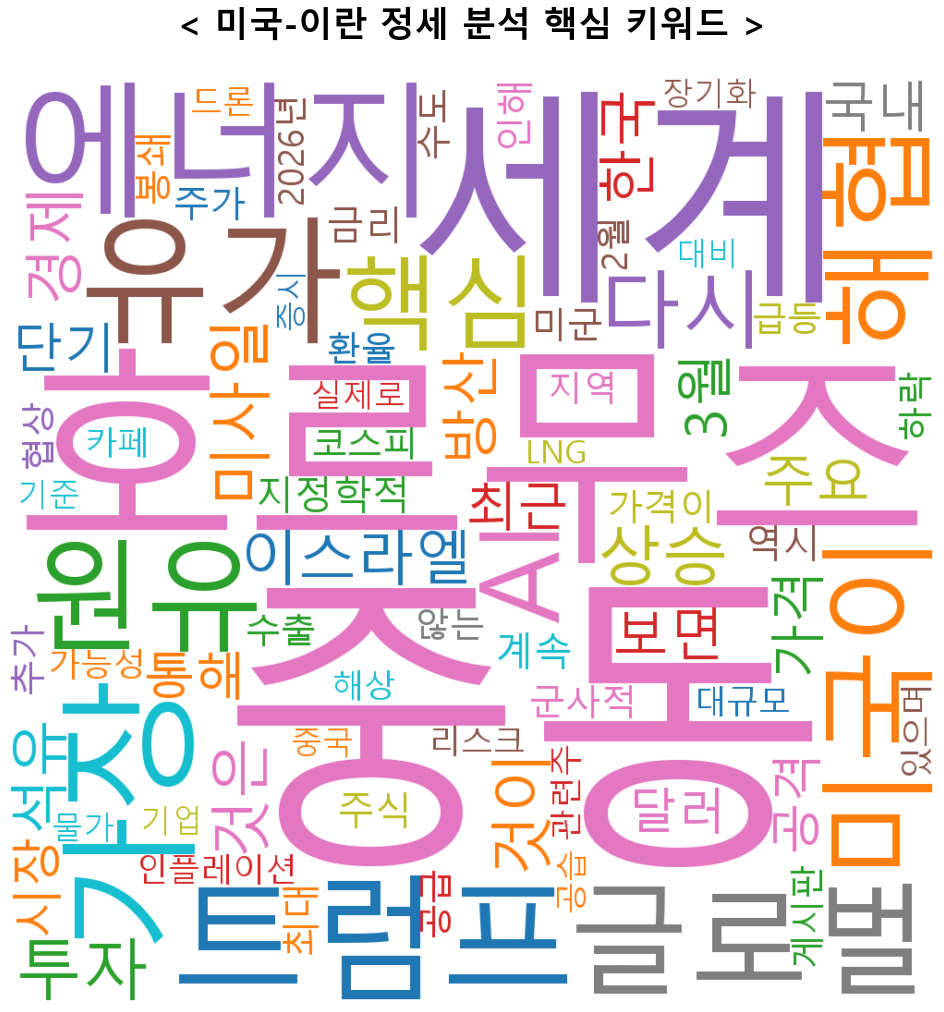

✅ 워드클라우드 생성이 완료되었으며 파일로 저장되었습니다!


In [28]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter

# 1. Matplotlib 한글 폰트 설정 (제목 깨짐 방지)
plt.rcParams['font.family'] = 'Malgun Gothic' 
plt.rcParams['axes.unicode_minus'] = False     

# 2. 데이터 준비: 재정제된 본문(Document) 명사 합치기
all_words_final = [word for doc in df_final['Document_token_noun'] for word in doc]
word_counts_final = Counter(all_words_final)

# 3. 워드클라우드 설정
font_path = 'C:/Windows/Fonts/malgun.ttf' 

wc_final = WordCloud(
    font_path=font_path,
    background_color='white',
    width=1000,
    height=1000,
    max_words=80,
    colormap='tab10',
    prefer_horizontal=0.7
)

# 4. 워드클라우드 생성
cloud_final = wc_final.generate_from_frequencies(word_counts_final)

# 5. [에러 지점 수정] 시각화 및 출력
plt.figure(figsize=(12, 12)) # 괄호를 정확히 닫았습니다.
plt.imshow(cloud_final, interpolation='bilinear')
plt.axis('off')

# 제목 설정
plt.title("< 미국-이란 정세 분석 핵심 키워드 >", fontsize=25, pad=30, fontweight='bold')

plt.show()

# 6. 결과 파일 저장
cloud_final.to_file('미국_이란_최종_워드클라우드_완성본.png')
print("✅ 워드클라우드 생성이 완료되었으며 파일로 저장되었습니다!")

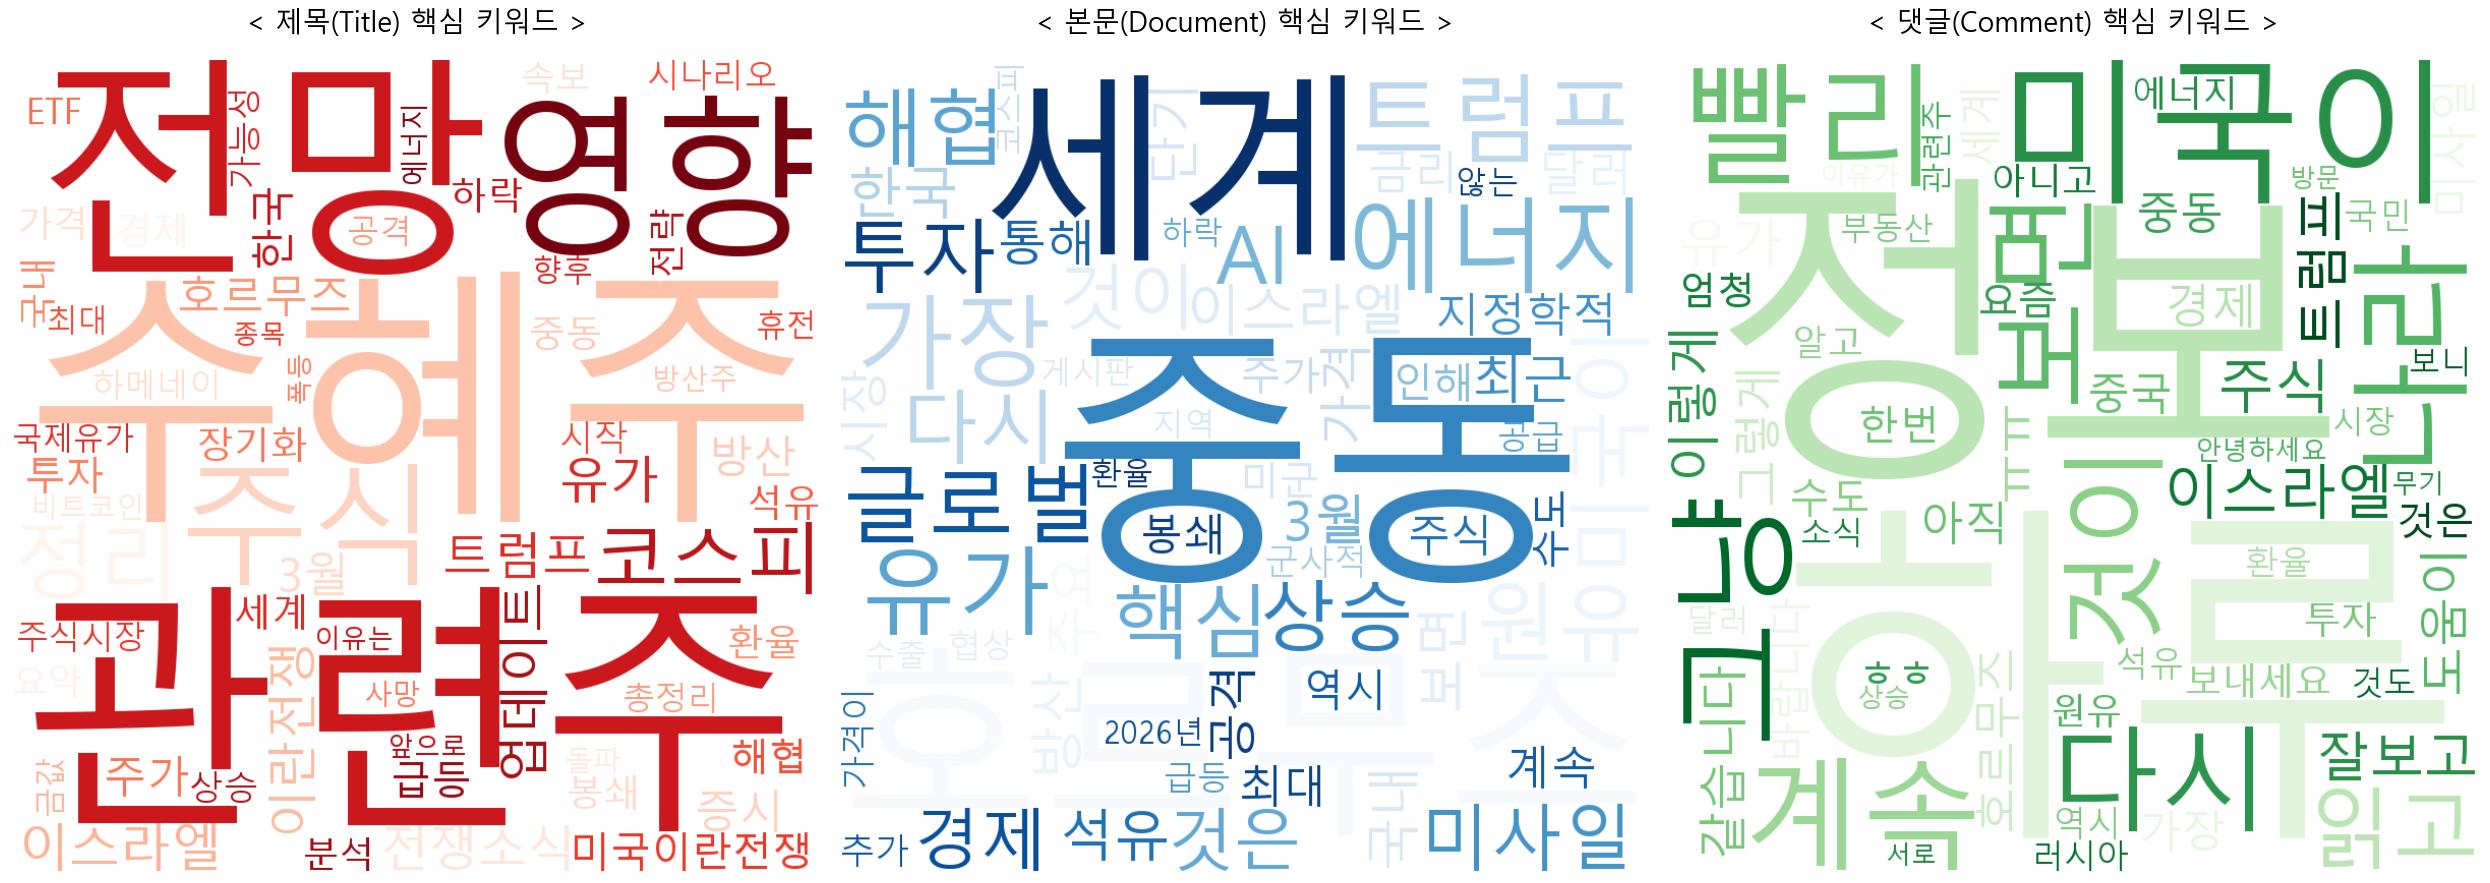

✅ 제목, 본문, 댓글 통합 워드클라우드 저장이 완료되었습니다!


In [29]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter

# 1. 한글 폰트 및 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
font_path = 'C:/Windows/Fonts/malgun.ttf'

# 2. 데이터 준비 및 빈도수 계산 함수
def get_counts(column_name):
    all_words = [word for doc in df_final[column_name] for word in doc]
    return Counter(all_words)

# 각 파트별 빈도수 추출
counts_title = get_counts('title_token_noun')
counts_doc = get_counts('Document_token_noun')
counts_comment = get_counts('comment_token_noun')

# 3. 워드클라우드 객체 생성 함수 (반복 작업 줄이기)
def create_wc(word_counts, color):
    return WordCloud(
        font_path=font_path,
        background_color='white',
        width=800, height=800,
        max_words=60,
        colormap=color
    ).generate_from_frequencies(word_counts)

# 4. 각 파트별 워드클라우드 생성 (색상을 다르게 해서 구분)
wc_title = create_wc(counts_title, 'Reds')      # 제목은 강렬하게 Red
wc_doc = create_wc(counts_doc, 'Blues')         # 본문은 신뢰감 있게 Blue
wc_comment = create_wc(counts_comment, 'Greens') # 댓글은 여론 느낌의 Green

# 5. 시각화 (서브플롯 활용하여 1행 3열 배치)
fig, axes = plt.subplots(1, 3, figsize=(25, 10))

# [제목 워드클라우드]
axes[0].imshow(wc_title, interpolation='bilinear')
axes[0].set_title("< 제목(Title) 핵심 키워드 >", fontsize=20, pad=20)
axes[0].axis('off')

# [본문 워드클라우드]
axes[1].imshow(wc_doc, interpolation='bilinear')
axes[1].set_title("< 본문(Document) 핵심 키워드 >", fontsize=20, pad=20)
axes[1].axis('off')

# [댓글 워드클라우드]
axes[2].imshow(wc_comment, interpolation='bilinear')
axes[2].set_title("< 댓글(Comment) 핵심 키워드 >", fontsize=20, pad=20)
axes[2].axis('off')

plt.tight_layout() # 그래프 간 간격 자동 조절
plt.show()

# 6. 이미지 저장
fig.savefig('파트별_통합_워드클라우드.png', dpi=300)
print("✅ 제목, 본문, 댓글 통합 워드클라우드 저장이 완료되었습니다!")

## TF-IDF : 단어의 빈도와 역 문서 빈도를 사용하여 DTM내의 각 단어마다 중요한 정도를 가중치로 주는 방법
### TF : 한 문서 내에서 특정 단어가 출현한 빈도수(문서내 출현 빈도가 높을수록 상대적으로 더 중요)
### IDF : 문서 집합의 전체 문서 수를 특정 단어가 나타나는 문서의 수로 나눈 값(높은 IDF 값을 가지는     단어는 문서 내에서 중요한 의미를 가지는 단어)
### TF-IDF : 두 값을 곱해서 사용하므로 어떤 단어가 해당 문서에 자주 등장하지만, 다른 문서에서는 출현 빈도가 낮을수록 높은 값을 가지게 됨

#### 즉, TF: 특정단어 등장빈도, DF: 특정단어 출현 문서 수, IDF: 특정단어 출현 문서 수의 역수
#### DTM(문서단어행렬) : 다수의 문서에서 등장하는 각 단어들의 빈도를 행렬로 표현한 것
#### 즉, 간 문서에 대한 BoW(Bag-of_Words)를 하나의 행렬로 만든것

In [30]:
# "본문"을 메인으로 하되, "댓글"과 비교해보는 방식 선정
# 제목은 텍스트가 얼마 없어서 계산 X
# 본문 TF-IDF: 이번 사건(미국-이란)의 실질적인 핵심 의제가 무엇인지 파악
# 댓글 TF-IDF: 기사 내용과는 별개로 사람들이 진짜로 걱정하거나 분노하는 포인트가 무엇인지 추출
#TF-IDF 계산을 위해 명사들의 문자열 구성
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

# 1. TF-IDF를 위해 토큰화된 리스트를 다시 문장(문자열)으로 합치기
def join_tokens(tokens):
    return " ".join(tokens)

# 본문과 댓글을 각각 하나의 리스트로 준비
doc_corpus = df_final['Document_token_noun'].apply(join_tokens)
comment_corpus = df_final['comment_token_noun'].apply(join_tokens)

# 2. TF-IDF 계산 함수
def get_tfidf_top_n(corpus, n=20):
    tfidf = TfidfVectorizer()
    tfidf_matrix = tfidf.fit_transform(corpus)
    
    # 단어별 평균 TF-IDF 점수 계산
    import numpy as np
    weights = np.asarray(tfidf_matrix.mean(axis=0)).ravel().tolist()
    weights_df = pd.DataFrame({'word': tfidf.get_feature_names_out(), 'weight': weights})
    
    return weights_df.sort_values(by='weight', ascending=False).head(n)

# 3. 결과 추출
tfidf_doc = get_tfidf_top_n(doc_corpus)
tfidf_comment = get_tfidf_top_n(comment_corpus)

# 4. 결과 출력
print("[본문] TF-IDF 기반 핵심 키워드 TOP 20")
display(tfidf_doc)

print("\n💬 [댓글] TF-IDF 기반 핵심 키워드 TOP 20")
display(tfidf_comment)

[본문] TF-IDF 기반 핵심 키워드 TOP 20


,word,weight
12989,호르무즈,0.026586
11903,트럼프,0.026083
4511,미국이,0.025854
10679,중동,0.025708
7624,에너지,0.025093
6410,세계,0.023568
1184,가장,0.022647
8431,유가,0.022601
8281,원유,0.020412
2530,글로벌,0.018678



💬 [댓글] TF-IDF 기반 핵심 키워드 TOP 20


,word,weight
3228,하루,0.040891
2660,정보,0.036064
1525,빨리,0.018571
2540,잘보고,0.015202
1214,미국이,0.012817
2426,읽고,0.012583
482,계속,0.011006
628,그냥,0.010166
1388,보면,0.009387
2776,주식,0.008981


## K-Means

#### 대표적인 클러스터링(비슷한 유형의 데이터를 그룹화) 알고리즘으로
#### K : 데이터의 세트에서 찾을 것으로 예상되는 클러스터(그룹) 수
#### Means : 각 데이터로부터 그 데이터가 속한 클러스터의 중심까지의 평균 거리

#### 최적분리 군집방법(K-Means clustering)은 하나 이상의 정량적 변수드로부터 유클리드 거리에 기초하여 군집이 형성됨.

In [ ]:
import threadpoolctl # 스레드 풀 제어를 위한 모듈

In [ ]:
# topic 결정하기, k-means clustering, 엘보우 기법

import matplotlib.pyplot as plt
from sklearn.cluter import KMenas
def elbow(X):
    sse = []

    for i in range(1, 10):
        km = KMenas(n_clusters=i, algorithm = 'auto', random_state = 0) # k-means algorithm: auto(기본값)
        km.fit(X)
        sse.append(km.inertia_)
        print(i)

    plt.plot(range(1,10), sse, marker='o')
    plt.xlabel('K')
    plt.ylabel('SSE')
    plt.xticks(range(1,10))
    plt.show()

elbow(X)

In [ ]:
model_x = KMenas(n_clusters = 2, random_state = 0)
model_x.fit(X)

print(model_x.cluster_centers_.shape)

In [ ]:
print("Doc Top terms for each cluster")
order_centroids = model_x.cluster_centers_.argsort()[:, ::-1]
terms_x = vec_x.get_feature_names_out()

for i in range(2):
    print("Cluster %d:" %)
    for ind in order_centroids[i, :50]:
        print('%s' % terms_x[ind])
    print('\n')